# NB07 - Rutas de regularizacion y seleccion de hiperparametros

**Objetivos de aprendizaje**

- Entender el concepto de ruta de regularizacion.
- Seleccionar `C` y `l1_ratio` con validacion cruzada estratificada.
- Visualizar la busqueda de hiperparametros.
- Comparar L1, L2 y Elastic Net en una tabla final.
- Conectar la eficiencia de rutas con descenso por coordenadas.

En todo el notebook mantenemos la convenci?n global del repositorio: `virginica = 1` es la clase positiva y `versicolor = 0` es la clase negativa.

**Referencias de este notebook**

- Friedman, Hastie & Tibshirani (2010): rutas de regularizacion para GLM mediante coordinate descent.
- Hastie, Tibshirani & Friedman (2009): validacion cruzada y seleccion de modelos.
- Pedregosa et al. (2011): scikit-learn como herramienta usada para pipelines, CV y metricas.


In [1]:
%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# Los notebooks pueden ejecutarse desde la raiz del repo o desde notebooks/.
# Este bloque localiza la raiz y agrega src/ al path de importacion.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from utils import (
    COLOR_PALETTE,
    RANDOM_STATE,
    get_train_test_split,
    load_binary_iris,
    load_processed_splits,
    plot_coefficients,
    plot_decision_boundary,
    plot_regularization_path,
    plot_sigmoid,
    save_processed_splits,
    set_plot_style,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
set_plot_style()
np.random.seed(RANDOM_STATE)

DATA_DIR = PROJECT_ROOT / "data" / "processed"

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline


## 1. Rutas completas de regularizacion

Una ruta evalua soluciones para muchos valores de `lambda` o `C`. Friedman, Hastie & Tibshirani (2010) mostraron que el descenso por coordenadas permite calcular estas rutas eficientemente en GLM, idea central detras de `glmnet`.


In [2]:
data = load_processed_splits(DATA_DIR)
X_train_scaled = data["X_train_scaled"]
X_test_scaled = data["X_test_scaled"]
y_train = data["y_train"]
y_test = data["y_test"]
feature_names = data["feature_names"]

C_values = np.logspace(-2, 2, 9)
l1_ratios = [0.1, 0.5, 0.9]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


## 2. Validacion cruzada para L2, L1 y Elastic Net


In [3]:
# Cada busqueda usa AUC promedio de validacion cruzada. Esto evita
# elegir hiperparametros mirando directamente el conjunto de test.
searches = {}

configs = {
    "L2": (
        LogisticRegression(penalty="l2", solver="lbfgs", max_iter=10000, random_state=RANDOM_STATE),
        {"C": C_values},
    ),
    "L1": (
        LogisticRegression(penalty="l1", solver="liblinear", max_iter=10000, random_state=RANDOM_STATE),
        {"C": C_values},
    ),
    "Elastic Net": (
        LogisticRegression(penalty="elasticnet", solver="saga", max_iter=20000, random_state=RANDOM_STATE),
        {"C": C_values, "l1_ratio": l1_ratios},
    ),
}

for name, (estimator, grid) in configs.items():
    search = GridSearchCV(
        estimator,
        param_grid=grid,
        scoring="roc_auc",
        cv=cv,
        refit=True,
        n_jobs=1,
        return_train_score=True,
    )
    search.fit(X_train_scaled, y_train)
    searches[name] = search
    print(f"{name}: mejores parametros = {search.best_params_}, AUC CV = {search.best_score_:.3f}")


L2: mejores parametros = {'C': np.float64(0.1)}, AUC CV = 1.000


L1: mejores parametros = {'C': np.float64(0.1)}, AUC CV = 1.000


Elastic Net: mejores parametros = {'C': np.float64(0.01), 'l1_ratio': 0.1}, AUC CV = 1.000


**Interpretacion.** La validacion cruzada estima rendimiento fuera de muestra usando solo entrenamiento. Hastie, Tibshirani & Friedman (2009) recomiendan este principio para que la seleccion de modelos no sobreajuste el test.


## 3. Visualizacion de la busqueda Elastic Net


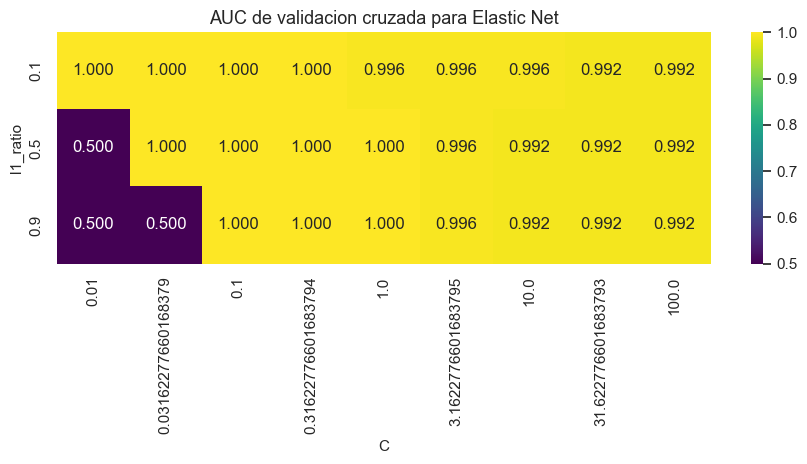

In [4]:
en_results = pd.DataFrame(searches["Elastic Net"].cv_results_)
en_results["C"] = en_results["param_C"].astype(float)
en_results["l1_ratio"] = en_results["param_l1_ratio"].astype(float)
heatmap_data = en_results.pivot(index="l1_ratio", columns="C", values="mean_test_score")

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="viridis", ax=ax)
ax.set_title("AUC de validacion cruzada para Elastic Net")
ax.set_xlabel("C")
ax.set_ylabel("l1_ratio")
fig.tight_layout()
plt.show()


**Interpretacion.** El mapa de calor permite ver regiones estables, no solo el maximo puntual. Si varios hiperparametros empatan, conviene preferir el mas simple o interpretable.


## 4. Comparacion final de penaltis


,penalti,mejores_parametros,features_no_cero,AUC_test,accuracy_test
0,L2,{'C': np.float64(0.1)},4,0.96,0.8667
1,L1,{'C': np.float64(0.1)},2,0.96,0.8667
2,Elastic Net,"{'C': np.float64(0.01), 'l1_ratio': 0.1}",4,0.96,0.9000


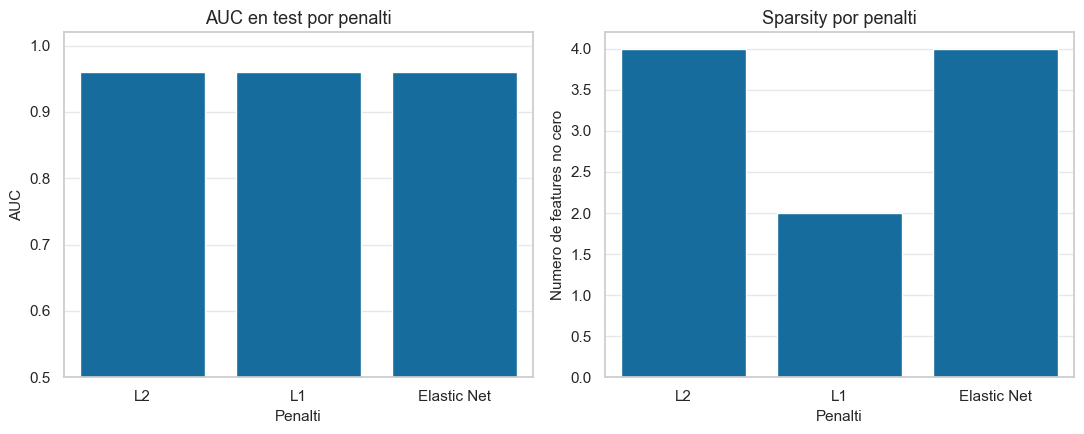

In [5]:
comparison_rows = []
for name, search in searches.items():
    best_model = search.best_estimator_
    test_prob = best_model.predict_proba(X_test_scaled)[:, 1]
    test_pred = best_model.predict(X_test_scaled)
    nonzero = int(np.sum(np.abs(best_model.coef_.ravel()) > 1e-8))
    comparison_rows.append(
        {
            "penalti": name,
            "mejores_parametros": str(search.best_params_),
            "features_no_cero": nonzero,
            "AUC_test": roc_auc_score(y_test, test_prob),
            "accuracy_test": accuracy_score(y_test, test_pred),
        }
    )

comparison = pd.DataFrame(comparison_rows)
display(comparison.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.barplot(data=comparison, x="penalti", y="AUC_test", ax=axes[0])
axes[0].set_title("AUC en test por penalti")
axes[0].set_xlabel("Penalti")
axes[0].set_ylabel("AUC")
axes[0].set_ylim(0.5, 1.02)

sns.barplot(data=comparison, x="penalti", y="features_no_cero", ax=axes[1])
axes[1].set_title("Sparsity por penalti")
axes[1].set_xlabel("Penalti")
axes[1].set_ylabel("Numero de features no cero")
fig.tight_layout()
plt.show()


**Interpretacion.** L1 puede ganar interpretabilidad apagando variables; L2 suele ser estable; Elastic Net busca un compromiso. Pedregosa et al. (2011) hacen posible comparar estas familias con una API comun en scikit-learn.


## 5. Coordinate descent

El descenso por coordenadas optimiza un coeficiente a la vez mientras mantiene fijos los demas. En problemas con penalizaciones separables como L1, esa estrategia puede ser muy eficiente y permite recorrer muchos valores de regularizacion usando soluciones previas como punto de partida.


## Resumen y conexion con la literatura

Friedman, Hastie & Tibshirani (2010) explican como calcular rutas de regularizacion de GLM mediante coordinate descent, idea que inspira la exploracion de muchos `C`. Hastie, Tibshirani & Friedman (2009) aportan la logica de validacion cruzada para seleccionar hiperparametros sin tocar el test. Pedregosa et al. (2011) documentan scikit-learn, la herramienta que usamos para ejecutar busquedas reproducibles y comparar modelos bajo una interfaz comun.
